In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import cholesky
from tqdm import tqdm
import cupy as cp
from cupy.linalg import eigh as cp_eigh

# ============================================================================
# Paramètres fixes
# ============================================================================
n_basis     = 10
sigma_noise = 0.05
sigma_coeff = 1.0
alpha       = 1.0
B           = 299
M           = 199
a_grid      = np.linspace(0, 0.16, 150)

n_vals = [100, 500]
p_vals = [100, 500, 1000]

C_CONST = (2.0 / 9.0) * np.exp(3)

def get_t(p):
    return (np.arange(1, p + 1) - 0.5) / p

def gen_fourier(a, n, t, seed):
    np.random.seed(seed)
    p     = len(t)
    basis = []
    for k in range(1, n_basis + 1):
        basis.append(0.25 * np.sin(np.pi * k * t))
        basis.append(0.25 * np.cos(np.pi * k * t))
    basis = np.array(basis).T
    curves = np.zeros((n, p))
    for i in range(n):
        coeff     = np.random.normal(0, sigma_coeff, size=2 * n_basis)
        noise     = np.random.normal(0, sigma_noise, size=p)
        curves[i] = a + basis @ coeff + noise
    return curves

def gen_brownian(a, n, t, seed):
    np.random.seed(seed)
    p  = len(t)
    dt = 1.0 / p
    increments = np.random.normal(0, np.sqrt(dt), size=(n, p))
    return a + np.cumsum(increments, axis=1)

def gen_white_noise(a, n, t, seed):
    np.random.seed(seed)
    p = len(t)
    return a + np.random.normal(0, 1.0, size=(n, p))

def gen_ou(a, n, t, seed, ell=0.2):
    np.random.seed(seed)
    p     = len(t)
    S_mat = np.exp(-np.abs(t[:, None] - t[None, :]) / ell)
    L     = cholesky(S_mat + 1e-10 * np.eye(p), lower=True)
    xi    = np.random.normal(0, 1, size=(n, p))
    return a + (L @ xi.T).T

def gen_flat_spectrum(a, n, t, seed):
    np.random.seed(seed)
    p = len(t)
    k = min(n, p)
    idx     = np.arange(p)
    E       = np.zeros((p, k))
    E[:, 0] = 1.0 / np.sqrt(p)
    for j in range(1, k):
        if j % 2 == 1:
            E[:, j] = np.sqrt(2.0 / p) * np.cos(2 * np.pi * ((j + 1) // 2) * idx / p)
        else:
            E[:, j] = np.sqrt(2.0 / p) * np.sin(2 * np.pi * (j // 2) * idx / p)
    xi = np.random.normal(0, 1.0 / np.sqrt(k), size=(n, k))
    return a + xi @ E.T

def theoretical_bound(eigvals, alpha, delta=0.05):
    c         = np.log(C_CONST / delta)
    ratios    = eigvals / (eigvals + alpha)
    Theta1    = np.sum(ratios)
    Theta2    = np.sqrt(np.sum(ratios**2))
    Theta_inf = np.max(ratios)
    return Theta1 + 2 * Theta2 * (np.sqrt(c) + (Theta_inf / Theta2) * c)

def get_ref_data(gen_func, n, p):
    t = get_t(p)
    return gen_func(0.0, n, t, seed=12345)

def run_np_gpu(args):
    gen_func, n, p, a_grid, alpha, B, M = args
    t     = get_t(p)
    Z_ref = get_ref_data(gen_func, n, p)

    Z_ref_cp          = cp.asarray(Z_ref)
    Gamma_ref         = (Z_ref_cp.T @ Z_ref_cp) / n
    eigvals_ref_cp, _ = cp_eigh(Gamma_ref)
    eigvals_ref       = cp.asnumpy(eigvals_ref_cp)[::-1]

    pw_perm  = np.zeros(len(a_grid))
    pw_bound = np.zeros(len(a_grid))

    for i, a in tqdm(enumerate(a_grid), total=len(a_grid),
                     desc=f"  n={n}, p={p}", leave=True):
        rej_perm  = 0
        rej_bound = 0
        bound     = theoretical_bound(eigvals_ref, alpha, delta=0.05)

        for rep in range(M):
            W = gen_func(a, n, t, seed=rep + i * 10000)
            Z     = cp.asarray(W)
            Gamma = (Z.T @ Z) / n
            eigvals_cp, eigvecs_cp = cp_eigh(Gamma)
            idx     = cp.argsort(eigvals_cp)[::-1]
            eigvals = eigvals_cp[idx]
            eigvecs = eigvecs_cp[:, idx]
            U     = Z @ eigvecs
            S     = U.sum(axis=0)
            denom = n * (eigvals + alpha)
            T_obs = float(cp.sum(S**2 / denom))

            if T_obs >= bound:
                rej_bound += 1

            signs  = cp.random.choice(cp.array([-1.0, 1.0]), size=(B, n))
            S_perm = signs @ U
            T_perm = cp.sum(S_perm**2 / denom, axis=1)
            p_val  = float((1 + cp.sum(T_perm >= T_obs)) / (B + 1))
            if p_val < 0.05:
                rej_perm += 1

        pw_perm[i]  = rej_perm  / M
        pw_bound[i] = rej_bound / M

    return (n, p), pw_perm, pw_bound

def plot_design(design_name, results_perm, results_bound, n_vals, p_vals, a_grid, save_dir):
    fig, axes = plt.subplots(len(n_vals), len(p_vals), figsize=(15, 10))
    for i, n in enumerate(n_vals):
        for j, p in enumerate(p_vals):
            ax = axes[i, j]
            ax.plot(a_grid, results_perm[(n, p)],
                    'r-o', linewidth=2, markersize=2, label='Sign-flip permutation')
            ax.plot(a_grid, results_bound[(n, p)],
                    'b-s', linewidth=2, markersize=2, label='Theoretical bound')
            ax.axhline(y=0.05, color='k', linestyle='--', linewidth=1, label='Nominal 5%')
            ax.set_title(f'n={n}, p={p}')
            ax.set_xlabel('a')
            ax.set_ylabel('Power')
            ax.set_ylim([-0.05, 1.05])
            ax.grid(True, linestyle=':')
            if i == 0 and j == 0:
                ax.legend(fontsize=8)
    title = design_name.replace('\n', ' ')
    plt.suptitle(
        f'One-sample test — {title}\n'
        'Red = sign-flip permutation  |  Blue = theoretical bound',
        fontsize=13
    )
    plt.tight_layout()
    fname = 'power_' + title.split('(')[0].strip().replace(' ', '_').lower()
    plt.savefig(f'{save_dir}/{fname}.pdf')
    plt.savefig(f'{save_dir}/{fname}.png', dpi=150)
    plt.show()
    print(f"  -> {fname}.png sauvegardé")

def plot_single_n(design_name, results_perm, results_bound, n, p_vals, a_grid, save_dir):
    """Affiche et sauvegarde les résultats pour un seul n."""
    fig, axes = plt.subplots(1, len(p_vals), figsize=(15, 5))
    for j, p in enumerate(p_vals):
        ax = axes[j]
        ax.plot(a_grid, results_perm[(n, p)],
                'r-o', linewidth=2, markersize=2, label='Sign-flip permutation')
        ax.plot(a_grid, results_bound[(n, p)],
                'b-s', linewidth=2, markersize=2, label='Theoretical bound')
        ax.axhline(y=0.05, color='k', linestyle='--', linewidth=1, label='Nominal 5%')
        ax.set_title(f'n={n}, p={p}')
        ax.set_xlabel('a')
        ax.set_ylabel('Power')
        ax.set_ylim([-0.05, 1.05])
        ax.grid(True, linestyle=':')
        if j == 0:
            ax.legend(fontsize=8)
    title = design_name.replace('\n', ' ')
    plt.suptitle(
        f'One-sample test — {title} — n={n}\n'
        'Red = sign-flip permutation  |  Blue = theoretical bound',
        fontsize=13
    )
    plt.tight_layout()
    fname = 'power_' + title.split('(')[0].strip().replace(' ', '_').lower() + f'_n{n}'
    plt.savefig(f'{save_dir}/{fname}.pdf')
    plt.savefig(f'{save_dir}/{fname}.png', dpi=150)
    plt.show()
    print(f"  -> {fname}.png sauvegardé")

# Brownian motion

  Design 1 (Brownian motion) — n=100


  n=100, p=1000: 100%|██████████| 100/100 [20:57<00:00, 12.57s/it]


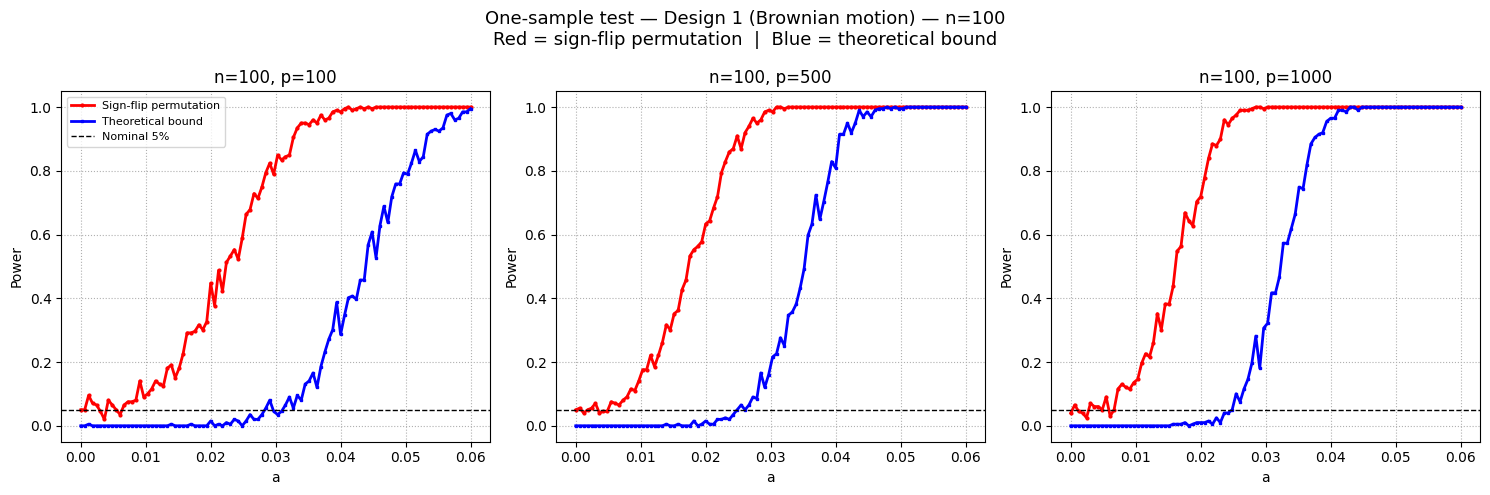

  -> power_design_1_n100.png sauvegardé


In [ ]:
design_name      = 'Design 1\n(Brownian motion)'
gen_func         = gen_brownian
save_dir         = '/content/drive/MyDrive/Graphics2'
n                = 100

print(f"{'='*60}\n  {design_name.replace(chr(10), ' ')} — n={n}\n{'='*60}")

tasks = [(gen_func, n, p, a_grid, alpha, B, M) for p in p_vals]

results_perm_d1  = {}
results_bound_d1 = {}

for (n_res, p), pw_perm, pw_bound in map(run_np_gpu, tasks):
    results_perm_d1[(n_res, p)]  = pw_perm
    results_bound_d1[(n_res, p)] = pw_bound

plot_single_n(design_name, results_perm_d1, results_bound_d1, n, p_vals, a_grid, save_dir)

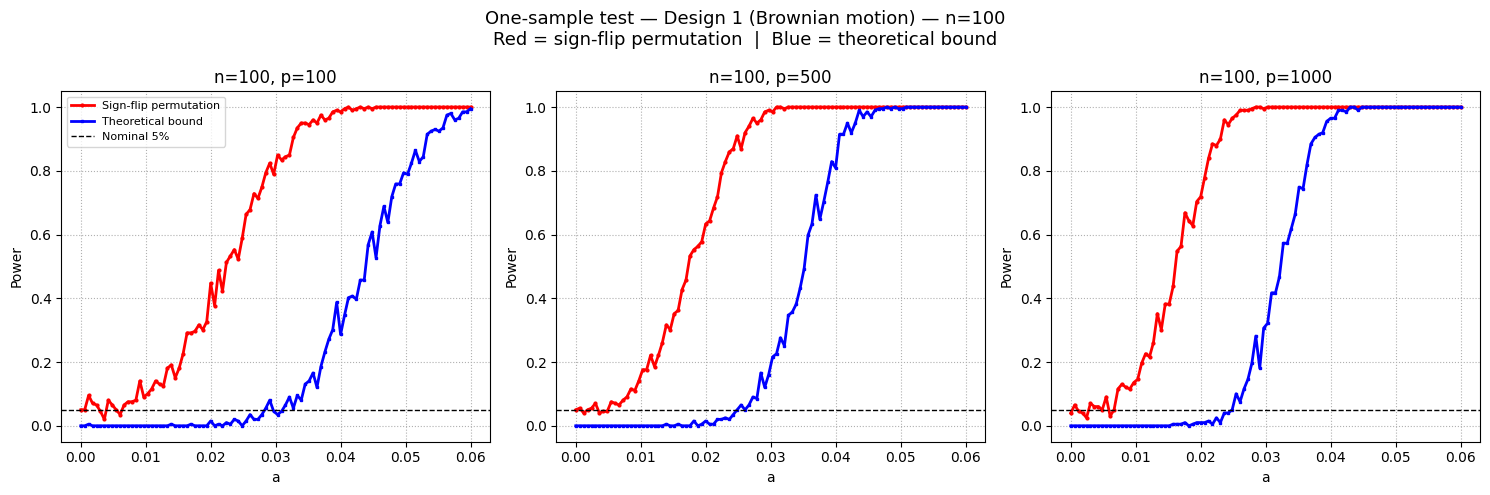

  -> power_design_1_n100.png sauvegardé


In [ ]:
plot_single_n(design_name, results_perm_d1, results_bound_d1, n, p_vals, a_grid, save_dir)

In [ ]:
import pickle

with open('/content/drive/MyDrive/Graphics2/results_d1_n100.pkl', 'wb') as f:
    pickle.dump({'perm': results_perm_d1, 'bound': results_bound_d1}, f)

In [ ]:
# # Code pour lire les fichiers sauvegardés

# with open('/content/drive/MyDrive/Graphics2/results_d1_n100.pkl', 'rb') as f:
#     data = pickle.load(f)
# results_perm_d1  = data['perm']
# results_bound_d1 = data['bound']

  Design 1 (Brownian motion) — n=500


  n=500, p=1000: 100%|██████████| 100/100 [29:54<00:00, 17.94s/it]


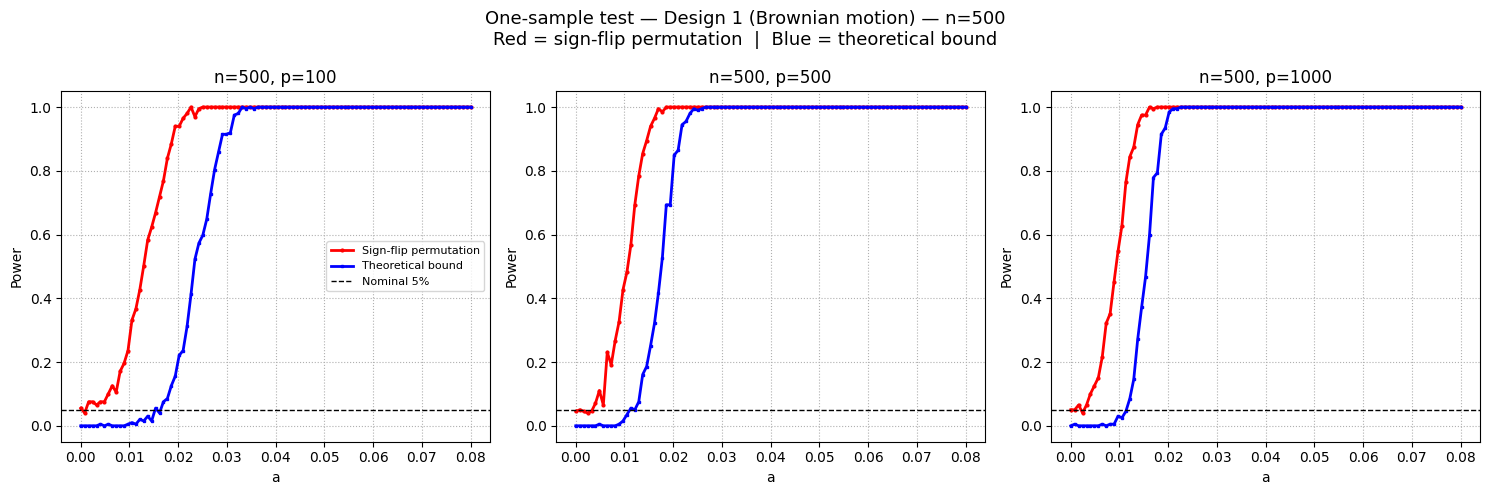

  -> power_design_1_n500.png sauvegardé


In [ ]:
design_name = 'Design 1\n(Brownian motion)'
gen_func    = gen_brownian
save_dir    = '/content/drive/MyDrive/Graphics2'
n           = 500

print(f"{'='*60}\n  {design_name.replace(chr(10), ' ')} — n={n}\n{'='*60}")

tasks = [(gen_func, n, p, a_grid, alpha, B, M) for p in p_vals]

for (n_res, p), pw_perm, pw_bound in map(run_np_gpu, tasks):
    results_perm_d1[(n_res, p)]  = pw_perm
    results_bound_d1[(n_res, p)] = pw_bound

plot_single_n(design_name, results_perm_d1, results_bound_d1, n, p_vals, a_grid, save_dir)

In [ ]:
import pickle

with open('/content/drive/MyDrive/Graphics2/results_d1_n500.pkl', 'wb') as f:
    pickle.dump({'perm': results_perm_d1, 'bound': results_bound_d1}, f)

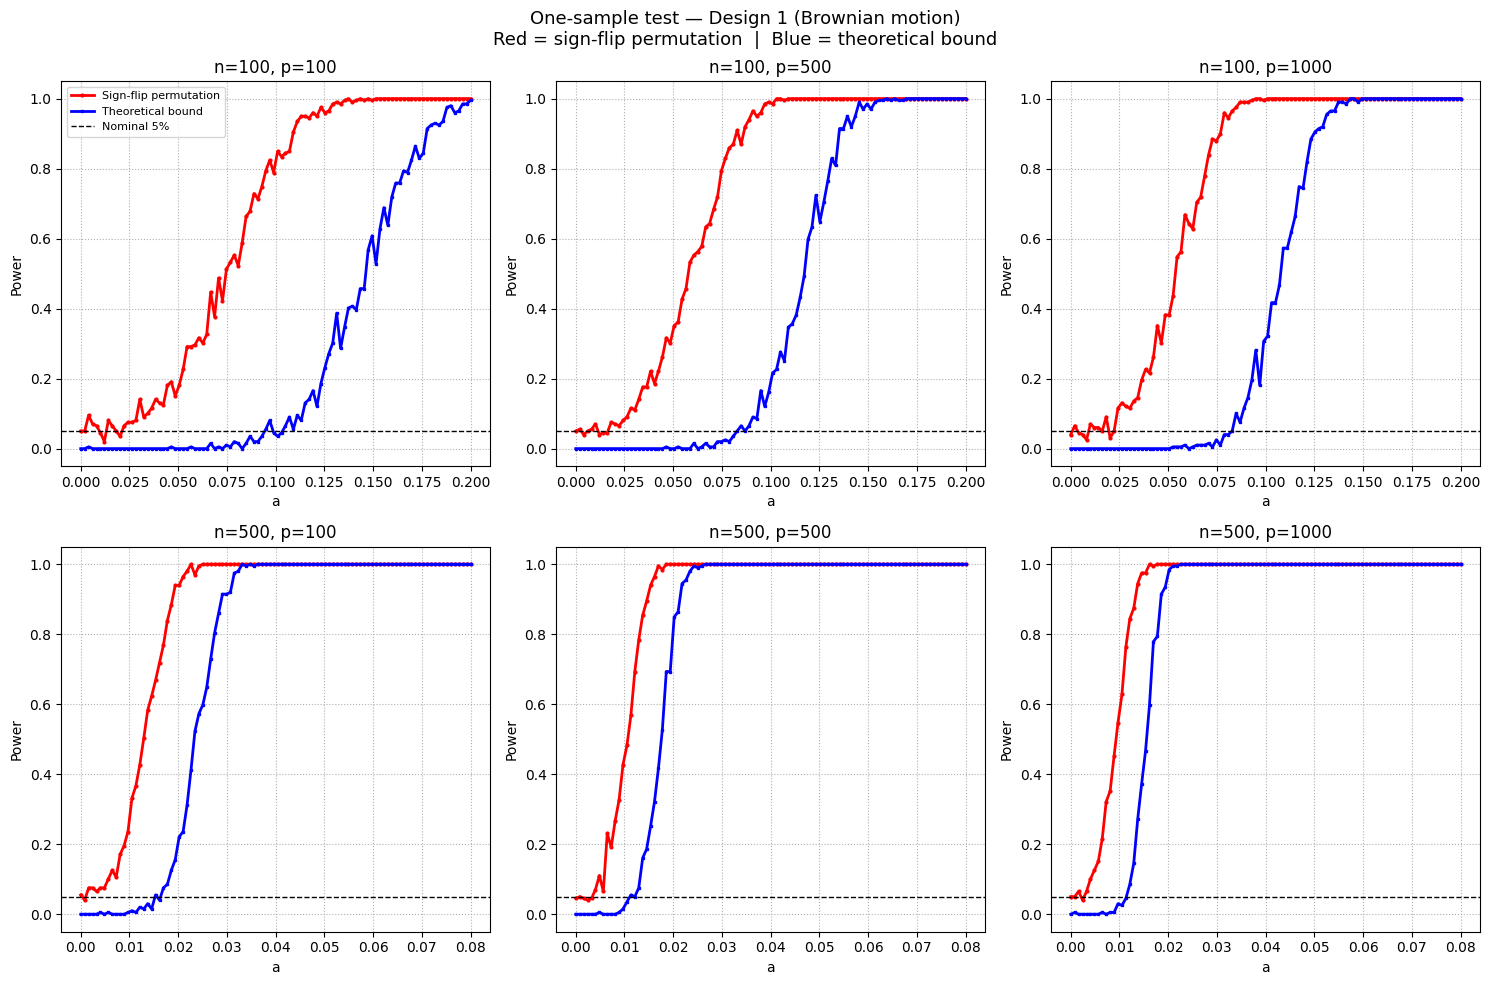

  -> power_design_1.png sauvegardé


In [ ]:
plot_design(design_name, results_perm_d1, results_bound_d1, n_vals, p_vals, a_grid, save_dir)

# Ornstein-Uhlenbeck

In [3]:
M           = 99
a_grid      = np.linspace(0, 0.6, 100)

  Design 3 (Ornstein-Uhlenbeck) — n=100


  n=100, p=1000: 100%|██████████| 100/100 [29:03<00:00, 17.43s/it]


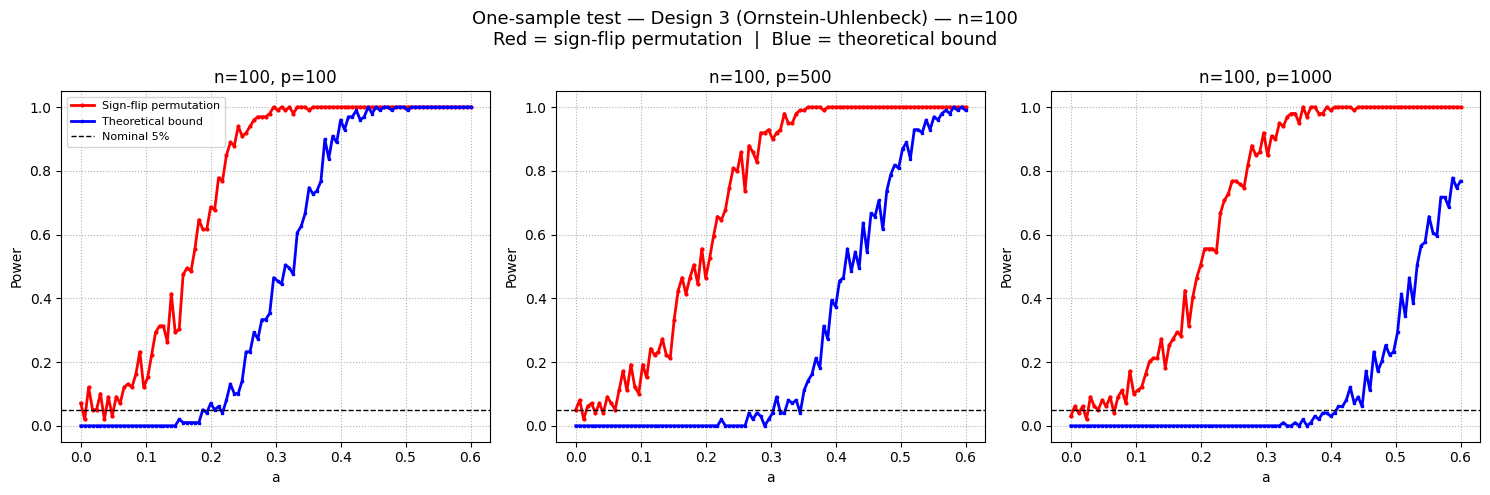

  -> power_design_3_n100.png sauvegardé


In [4]:
design_name      = 'Design 3\n(Ornstein-Uhlenbeck)'
gen_func         = gen_ou
save_dir         = '/content/drive/MyDrive/Graphics2'
n                = 100

print(f"{'='*60}\n  {design_name.replace(chr(10), ' ')} — n={n}\n{'='*60}")

tasks = [(gen_func, n, p, a_grid, alpha, B, M) for p in p_vals]

results_perm_d3  = {}
results_bound_d3 = {}

for (n_res, p), pw_perm, pw_bound in map(run_np_gpu, tasks):
    results_perm_d3[(n_res, p)]  = pw_perm
    results_bound_d3[(n_res, p)] = pw_bound

plot_single_n(design_name, results_perm_d3, results_bound_d3, n, p_vals, a_grid, save_dir)

In [5]:
import pickle

with open('/content/drive/MyDrive/Graphics2/results_d3_n100.pkl', 'wb') as f:
    pickle.dump({'perm': results_perm_d3, 'bound': results_bound_d3}, f)

  Design 3 (Ornstein-Uhlenbeck) — n=500


  n=500, p=1000: 100%|██████████| 100/100 [38:31<00:00, 23.11s/it]


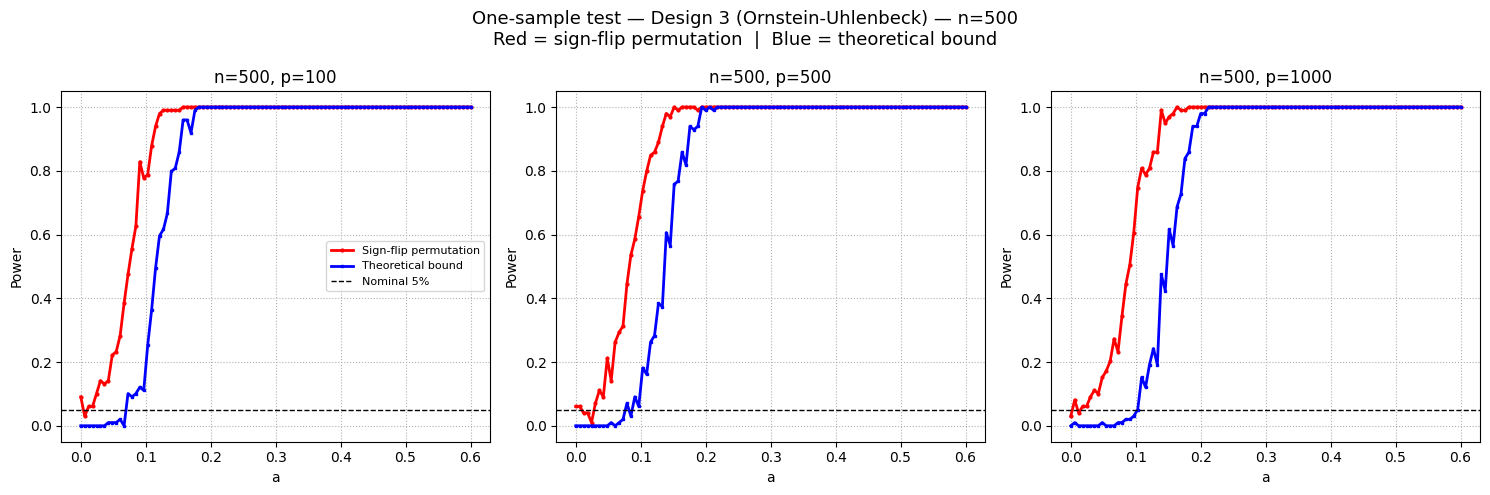

  -> power_design_3_n500.png sauvegardé


In [6]:
design_name = 'Design 3\n(Ornstein-Uhlenbeck)'
gen_func    = gen_ou
save_dir    = '/content/drive/MyDrive/Graphics2'
n           = 500

print(f"{'='*60}\n  {design_name.replace(chr(10), ' ')} — n={n}\n{'='*60}")

tasks = [(gen_func, n, p, a_grid, alpha, B, M) for p in p_vals]

for (n_res, p), pw_perm, pw_bound in map(run_np_gpu, tasks):
    results_perm_d3[(n_res, p)]  = pw_perm
    results_bound_d3[(n_res, p)] = pw_bound

plot_single_n(design_name, results_perm_d3, results_bound_d3, n, p_vals, a_grid, save_dir)

In [8]:
import pickle

with open('/content/drive/MyDrive/Graphics2/results_d3_n500.pkl', 'wb') as f:
    pickle.dump({'perm': results_perm_d3, 'bound': results_bound_d3}, f)

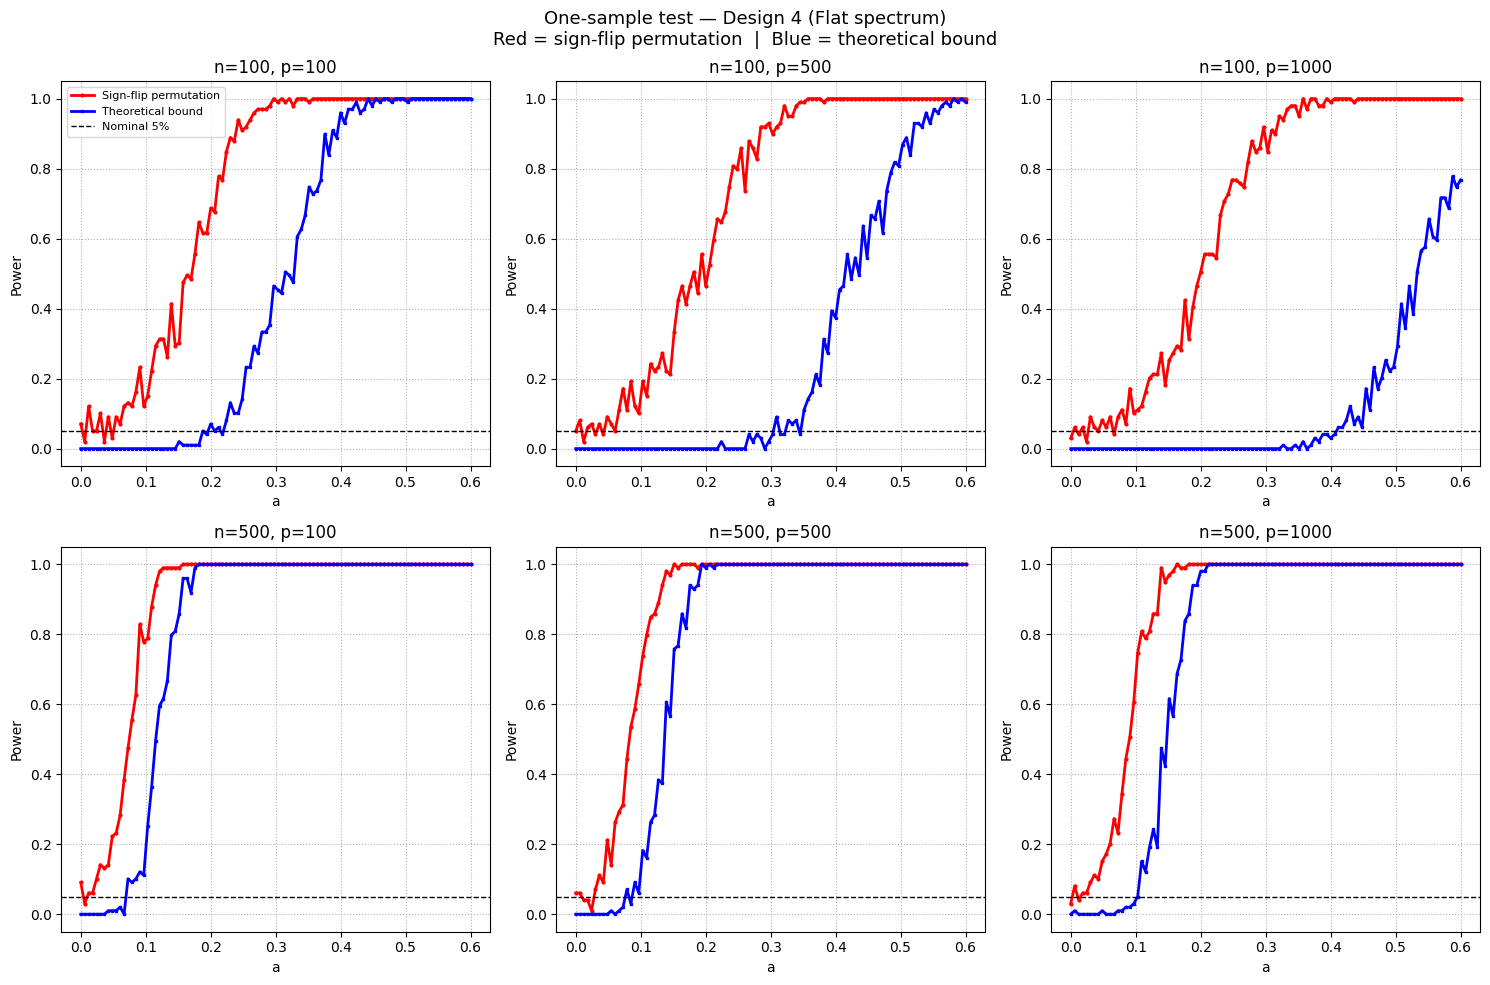

  -> power_design_4.png sauvegardé


In [9]:
plot_design(design_name, results_perm_d3, results_bound_d3, n_vals, p_vals, a_grid, save_dir)

# Flat spectrum

In [6]:
a_grid      = np.linspace(0, 0.015, 150)

  Design 4 (Flat spectrum) — n=100


  n=100, p=1000: 100%|██████████| 150/150 [33:31<00:00, 13.41s/it]


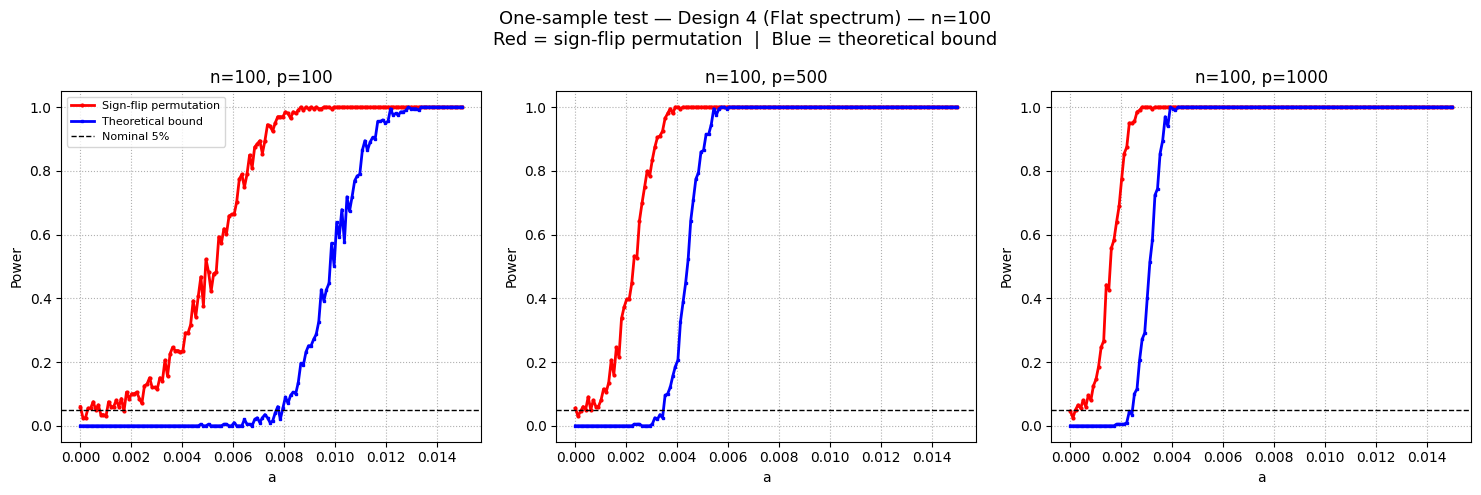

  -> power_design_4_n100.png sauvegardé


In [7]:
design_name      = 'Design 4\n(Flat spectrum)'
gen_func         = gen_flat_spectrum
save_dir         = '/content/drive/MyDrive/Graphics2'
n                = 100

print(f"{'='*60}\n  {design_name.replace(chr(10), ' ')} — n={n}\n{'='*60}")

tasks = [(gen_func, n, p, a_grid, alpha, B, M) for p in p_vals]

results_perm_d4  = {}
results_bound_d4 = {}

for (n_res, p), pw_perm, pw_bound in map(run_np_gpu, tasks):
    results_perm_d4[(n_res, p)]  = pw_perm
    results_bound_d4[(n_res, p)] = pw_bound

plot_single_n(design_name, results_perm_d4, results_bound_d4, n, p_vals, a_grid, save_dir)

In [8]:
import pickle

with open('/content/drive/MyDrive/Graphics2/results_d4_n100.pkl', 'wb') as f:
    pickle.dump({'perm': results_perm_d4, 'bound': results_bound_d4}, f)

  Design 4 (Flat spectrum) — n=500


  n=500, p=1000: 100%|██████████| 150/150 [1:02:45<00:00, 25.11s/it]


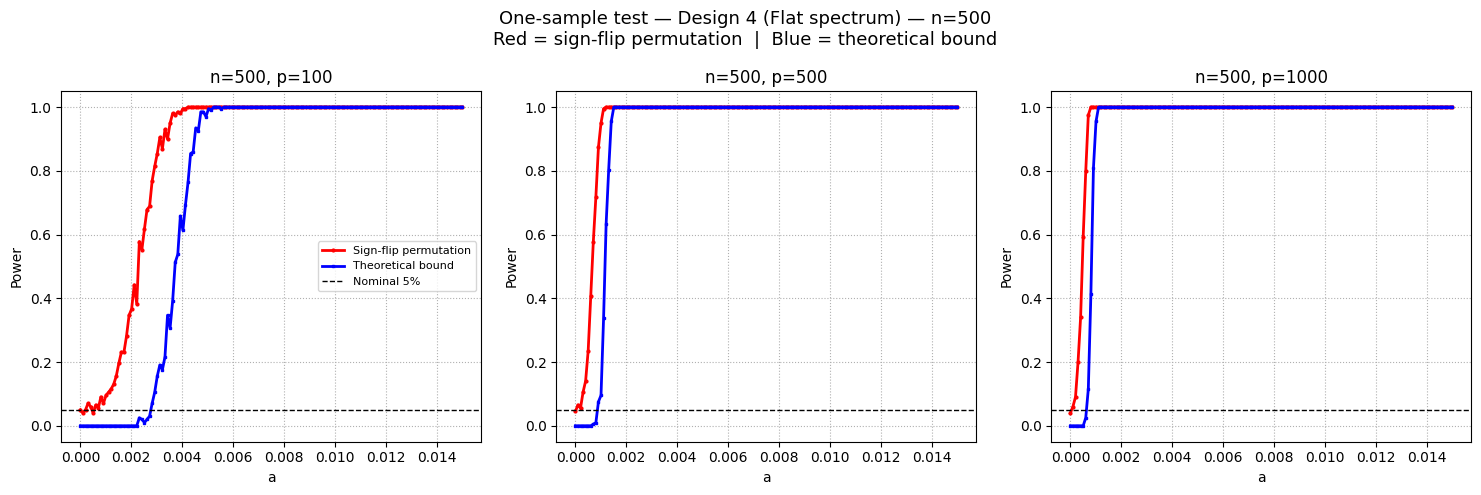

  -> power_design_4_n500.png sauvegardé


In [9]:
design_name = 'Design 4\n(Flat spectrum)'
gen_func    = gen_flat_spectrum
save_dir    = '/content/drive/MyDrive/Graphics2'
n           = 500

print(f"{'='*60}\n  {design_name.replace(chr(10), ' ')} — n={n}\n{'='*60}")

tasks = [(gen_func, n, p, a_grid, alpha, B, M) for p in p_vals]

for (n_res, p), pw_perm, pw_bound in map(run_np_gpu, tasks):
    results_perm_d4[(n_res, p)]  = pw_perm
    results_bound_d4[(n_res, p)] = pw_bound

plot_single_n(design_name, results_perm_d4, results_bound_d4, n, p_vals, a_grid, save_dir)

In [10]:
import pickle

with open('/content/drive/MyDrive/Graphics2/results_d4_n500.pkl', 'wb') as f:
    pickle.dump({'perm': results_perm_d4, 'bound': results_bound_d4}, f)

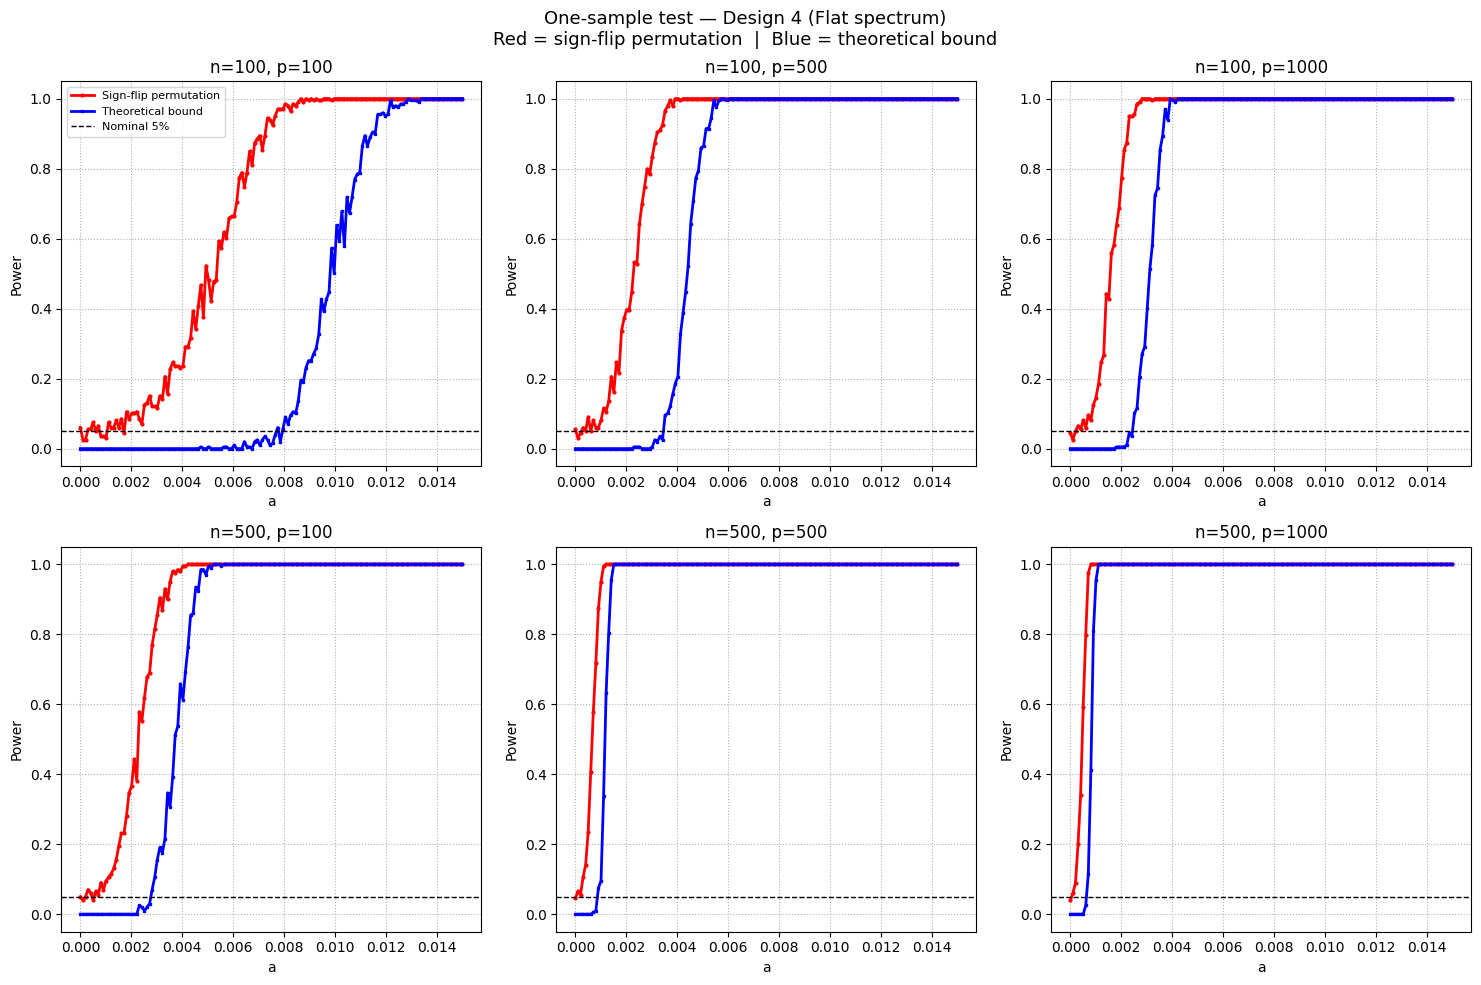

  -> power_design_4.png sauvegardé


In [11]:
plot_design(design_name, results_perm_d4, results_bound_d4, n_vals, p_vals, a_grid, save_dir)